# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 33     |  |
| :-------------|:-------------|
| Jens Groen| 6353991 |
| Tom Jongbloed| 6581048 |
| Celeste de Jong| 6290728 |
| Planning Groep: 33     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1 | Tijdstip |
| Mijlpaal 2 | Tijdstip |
| groep aanwezig 1| Tijdspanne |
| groep aanwezig 2| Tijdspanne |
| Pauze 1| Tijdspanne |
| Pauze 2| Tijdspanne |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="tudelftLogo.png" alt="schets student 1" width="400"/>

In [89]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
import numpy as np
Vout = 225*10**-3

def Cmetingen(Vout):
    Cmeting = Vout/(16* np.pi* 2 * 100*10**3*1000)*10**12
    return Cmeting




def vlakkeplaat(A, d, eps_r):
    """
    Capaciteit van een vlakke plaat condensator.
    A = oppervlakte (m^2)
    d = afstand tussen platen (m)
    eps_r = relatieve permittiviteit (default = 1 voor lucht/vacuüm)
    """
    eps0 = 8.85418782e-12
    eps = eps0 * eps_r
    C = eps * A / d
    return C


# ---- gegeven waarden ----
# 1) vlakke plaat: 10 cm x 10 cm, d = 1 mm
A1 = (0.10) * (0.10)     # m^2
d1 = 44e-3                # m
eps_r = 1.3
to_pF = 1e12
C1_air = vlakkeplaat(A1, d1, eps_r)
V =  C1_air*16*2*np.pi*10**8
print("meting C osciloscoop:", Cmetingen(Vout), "pF")
print("1) Vlakke plaat (10cm x 10cm, d=1mm, lucht):")
print("   C =", C1_air * to_pF, "pF\n")
print(V)
# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

meting C osciloscoop: 22.38116387229778 pF
1) Vlakke plaat (10cm x 10cm, d=1mm, lucht):
   C = 2.616010037727274 pF

0.026299001331971716


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](metingkartonnenplaten.jpg)
![scope meting 2](osciloscoop.jpg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 33| 203.64631986000003 pF |2.0472761036888745 Vpp|  1.7 Vpp |169.10212703513878 pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](3sensoren.jpg)


## Opdracht 3: Welke sensor gaan jullie maken?

Wij gaan een sensor maken die een keukenweegschaal nabootst, een gewichsensor waarbij de condensatorplaten tussen een stuk schuim zit

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](fotooo.jpg)

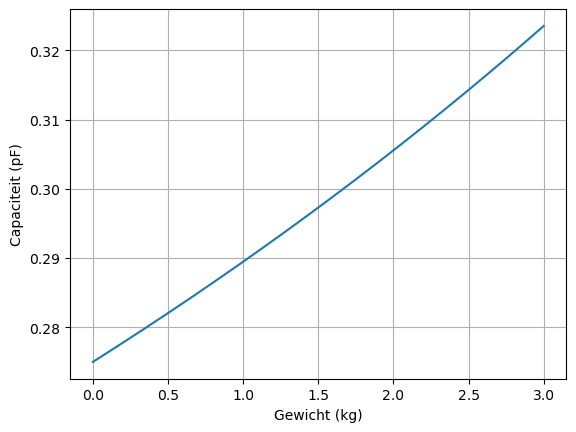

In [85]:
import numpy as np
import matplotlib.pyplot as plt

Cmin = 8.455106351756939   # pF
Cmax = 30.239439187460114  # pF
D_0 = 0.04
D_1 = 0.036
m = 2
g = 9.81
veerconstante_schuim = -m*g/(D_1-D_0)

m0 = 1.5     # kg (midden)
s  = 0.326   # kg (scherpte)

m_test = np.linspace(0, 3, 200)  # 0..3 g

#C = Cmin + (Cmax - Cmin) / (1 + np.exp(-(m - m0)/s))
C = (eps_r*A1)/(D_0-((m_test*g)/veerconstante_schuim))
plt.plot(m_test, C)
plt.xlabel("Gewicht (kg)")
plt.ylabel("Capaciteit (pF)")
plt.grid(True)
plt.show()

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 8.455106351756939 pF |88.89 mVpp |
| gemiddelde capaciteit| 24.37060066094647 pF | 240 mVpp |
| maximale capaciteit| 30.239439187460114 pF |300 mVpp |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](foto1.jpg)
![meting 2](foto2.jpg)

## Opdracht 7: Plot de kalibratiegrafiek.

C:\Users\jensj\AppData\Local\Temp\ipykernel_23320\1011984311.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


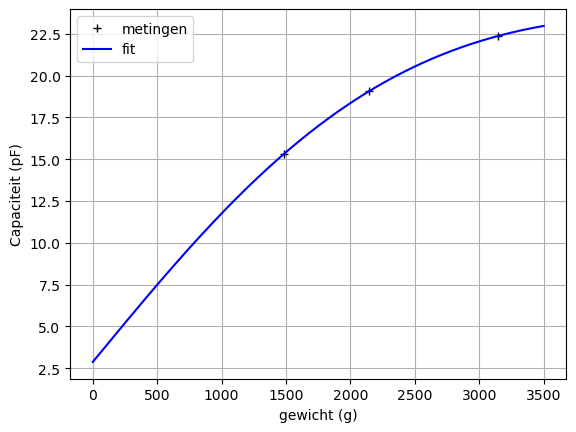

In [99]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
from scipy.optimize import curve_fit
#metingen
Cmin = 8.455106351756939   # pF
Cmax = 30.239439187460114  # pF
Marray = np.array([2142,1485,3148])

Carray = np.array([19.06,15.33,22.38])

def veercapaciteit(m, a, b, c):
    D_0 = 0.04
    g = 9.81                
    eps_r = 1.3
    A1 = 0.10 * 0.10
    eps0 = 8.85418782e-12

    m = m / 1000             

    F = m * g
    k = a*(F - b)**2 + c

    d = D_0 - (F/k)
    C = (eps_r*eps0*A1)/d

    return C * 1e12       


p0 = [1e3, 10, 1e3]

popt, pcov = curve_fit(
    veercapaciteit,
    Marray,
    Carray,
    p0=p0,
    maxfev=20000
)

x_test = np.linspace(0, 3500, 1000)
y_test = veercapaciteit(x_test, *popt)

plt.plot(Marray, Carray, 'k+', label="metingen")
plt.plot(x_test, y_test, 'b-', label="fit")

plt.ylabel("Capaciteit (pF)")
plt.xlabel("gewicht (g)")
plt.grid(True)
plt.legend()
plt.show()


## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* oxidatielaag weghalen
* het schuim vlak maken

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](foto1.jpg)

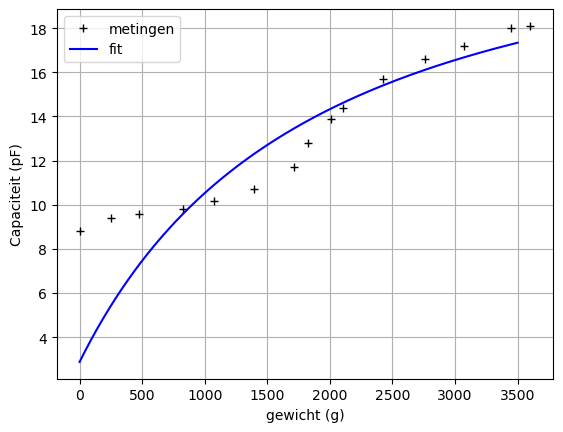

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# metingen
Cmin = 8.455106351756939   # pF
Cmax = 30.239439187460114  # pF

Marray = np.array([0,1075.6,830.4,1390.5,2103.8,2424.7,2762.7,
                   3075.1,3443.7,3603.3,2005.6,1825.2,1717.3,
                   477.5,249.2])

Carray = np.array([8.8,10.15,9.8,10.7,14.4,15.7,16.6,17.2,
                   18,18.1,13.9,12.8,11.7,9.6,9.4])


def veercapaciteit(m, a, b, c):
    D_0 = 0.04
    g = 9.81                
    eps_r = 1.3
    A1 = 0.10 * 0.10
    eps0 = 8.85418782e-12

    m = m / 1000             

    F = m * g
    k = a*(F - b)**2 + c

    d = D_0 - (F/k)
    C = (eps_r*eps0*A1)/d

    return C * 1e12       


p0 = [1e3, 10, 1e3]

popt, pcov = curve_fit(
    veercapaciteit,
    Marray,
    Carray,
    p0=p0,
    maxfev=20000
)

x_test = np.linspace(0, 3500, 1000)
y_test = veercapaciteit(x_test, *popt)

plt.plot(Marray, Carray, 'k+', label="metingen")
plt.plot(x_test, y_test, 'b-', label="fit")

plt.ylabel("Capaciteit (pF)")
plt.xlabel("gewicht (g)")
plt.grid(True)
plt.legend()
plt.show()

## Opdracht 10: Vul hieronder de conclusie in.

De gekozen applicatie van onze sensor was een keukenweegschaal. Aan onze meetgegevens is te zien dat de grafiek een s curve heeft, waar tussen de 0 en 1000 g en vanaf de 3000 g en zwaarder enorm afvlakt. Dit betekent dat bij die range de massa niet exact genoeg kan worden gemeten door te kijken naar de verandering van de capaciteit. De applicatie als keukenweegschaal is dus niet geschikt. 


Bij de test simulatie is … de veerconstante wordt zo stug dat er geen verandering in massa wordt gemeten

Verschil tussen kalibratie grafiek, dit verschil zit in het weghalen van de oxidatie laag. 


Als verbetering vertellen over dat er eerst meer lucht tussen zit en het materiaal van de spons

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.